<a href="https://colab.research.google.com/github/Arnav-Patil-456/eda_tools/blob/main/ml_project_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import os
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# 1. Automatic acquisition if files are not detected in directory
if not os.path.exists('secom.data'):
    print("Downloading secom.data from UCI...")
    urllib.request.urlretrieve(
        "https://archive.ics.uci.edu/ml/machine-learning-databases/secom/secom.data",
        "secom.data"
    )

if not os.path.exists('secom_labels.data'):
    print("Downloading secom_labels.data from UCI...")
    urllib.request.urlretrieve(
        "https://archive.ics.uci.edu/ml/machine-learning-databases/secom/secom_labels.data",
        "secom_labels.data"
    )

# 2. Parse sensor matrix and labels
X_raw = pd.read_csv('secom.data', sep=r'\s+', header=None)
y_raw_full = pd.read_csv('secom_labels.data', sep=r'\s+', header=None)
y_raw = y_raw_full.iloc[:, 0]

X_raw.columns = [f"Sensor_{i}" for i in range(X_raw.shape[1])]

print("Raw Feature Matrix Shape (X):", X_raw.shape)
print("Raw Target Vector Shape (y) :", y_raw.shape)
print("Class counts (-1: Pass, 1: Fail):\n", y_raw.value_counts())

Raw Feature Matrix Shape (X): (1567, 590)
Raw Target Vector Shape (y) : (1567,)
Class counts (-1: Pass, 1: Fail):
 0
-1    1463
 1     104
Name: count, dtype: int64


Pass count (0): 1463 (93.36%)
Fail count (1): 104 (6.64%)


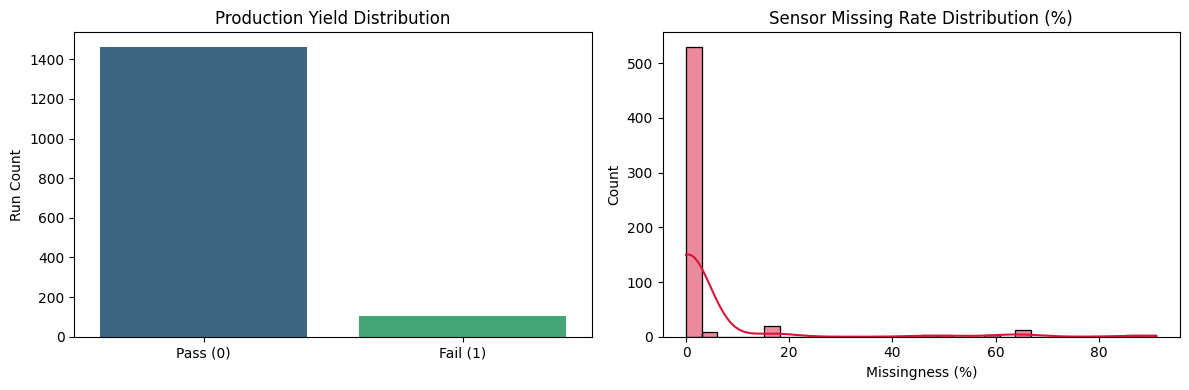

In [6]:
# 1. Target vector conversion (-1 -> 0 Pass, 1 -> 1 Fail)
y = y_raw.apply(lambda val: 1 if val == 1 else 0)

# 2. Class imbalance inspection
counts = y.value_counts()
print(f"Pass count (0): {counts[0]} ({counts[0] / len(y) * 100:.2f}%)")
print(f"Fail count (1): {counts[1]} ({counts[1] / len(y) * 100:.2f}%)")

# 3. Visualizations: Distribution & Missingness profile
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.barplot(x=['Pass (0)', 'Fail (1)'], y=[counts[0], counts[1]], palette='viridis')
plt.title("Production Yield Distribution")
plt.ylabel("Run Count")

plt.subplot(1, 2, 2)
missing_rate = (X_raw.isnull().sum() / len(X_raw)) * 100
sns.histplot(missing_rate, bins=30, color='crimson', kde=True)
plt.title("Sensor Missing Rate Distribution (%)")
plt.xlabel("Missingness (%)")

plt.tight_layout()
plt.show()

In [9]:
# 1. Drop sensors exceeding 50% missing values
high_missing_thresh = 50.0
cols_to_drop = missing_rate[missing_rate > high_missing_thresh].index.tolist()
print(f"Sensors with > 50% missing values dropped: {len(cols_to_drop)}")
X_step1 = X_raw.drop(columns=cols_to_drop)

# 2. Drop constant / zero-variance columns (std == 0)
zero_var_cols = [c for c in X_step1.columns if X_step1[c].dropna().nunique() <= 1]
print(f"Constant/Zero-variance sensors dropped: {len(zero_var_cols)}")
X_cleaned = X_step1.drop(columns=zero_var_cols)

print(f"Remaining active sensors: {X_cleaned.shape[1]} (from original {X_raw.shape[1]})")

Sensors with > 50% missing values dropped: 28
Constant/Zero-variance sensors dropped: 116
Remaining active sensors: 446 (from original 590)


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# 1. Stratified 80/20 train/test split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_cleaned, y, test_size=0.20, random_state=42, stratify=y
)

# 2. Median imputation fit solely on training data
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train_raw)
X_test_imp = imputer.transform(X_test_raw)

# 3. Standardization fit solely on training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled = scaler.transform(X_test_imp)

feature_names = X_cleaned.columns.tolist()
print(f"Training split dimensions: {X_train_scaled.shape}")
print(f"Testing split dimensions : {X_test_scaled.shape}")

Training split dimensions: (1253, 446)
Testing split dimensions : (314, 446)


Cumulative Variance explained by 20 components: 39.76%


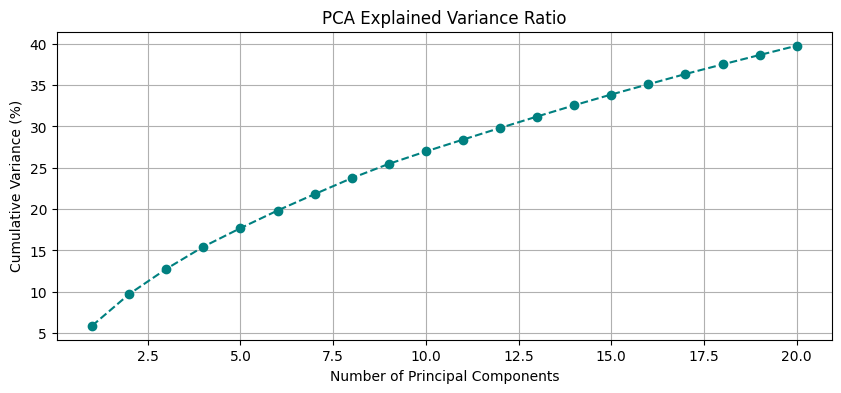

=== K-MEANS REGIME FAILURE AUDIT ===
         count  Failures  Failure_Rate
Cluster                               
0         1223        78      0.063778
1            4         1      0.250000
2           26         4      0.153846


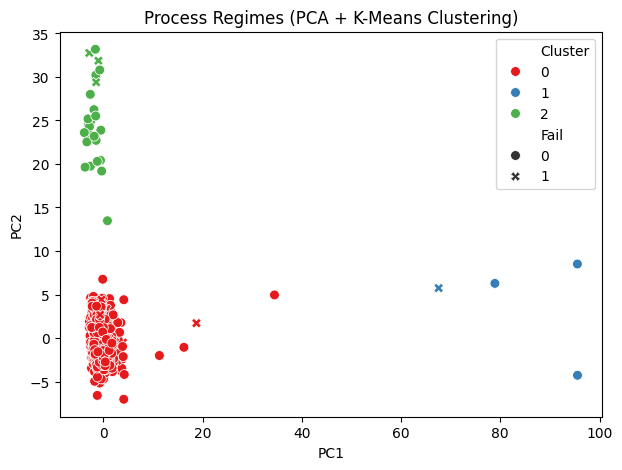

In [11]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# 1. PCA variance decomposition
pca = PCA(n_components=20, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

exp_var_cumsum = np.cumsum(pca.explained_variance_ratio_) * 100
print(f"Cumulative Variance explained by 20 components: {exp_var_cumsum[-1]:.2f}%")

# 2. Scree plot
plt.figure(figsize=(10, 4))
plt.plot(range(1, 21), exp_var_cumsum, marker='o', linestyle='--', color='teal')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Variance (%)")
plt.title("PCA Explained Variance Ratio")
plt.grid(True)
plt.show()

# 3. K-Means clustering on first 2 PCs
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
train_clusters = kmeans.fit_predict(X_train_pca[:, :2])

df_clusters = pd.DataFrame({
    'PC1': X_train_pca[:, 0],
    'PC2': X_train_pca[:, 1],
    'Cluster': train_clusters,
    'Fail': y_train.values
})

# Cluster failure inspection
cluster_stats = df_clusters.groupby('Cluster')['Fail'].agg(['count', 'sum', 'mean']).rename(
    columns={'sum': 'Failures', 'mean': 'Failure_Rate'}
)
print("=== K-MEANS REGIME FAILURE AUDIT ===")
print(cluster_stats)

# Visualizing operating clusters
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df_clusters, x='PC1', y='PC2', hue='Cluster', style='Fail', palette='Set1', s=50)
plt.title("Process Regimes (PCA + K-Means Clustering)")
plt.show()

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced', max_depth=6, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
        auc = roc_auc_score(y_test, y_prob)
    else:
        auc = np.nan

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    results.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall (Fail)": round(rec, 4),
        "F1-Score": round(f1, 4),
        "ROC-AUC": round(auc, 4)
    })

eval_df = pd.DataFrame(results)
print("=== CLASSIFIER COMPARISON BENCHMARK ===")
print(eval_df.to_string(index=False))

=== CLASSIFIER COMPARISON BENCHMARK ===
              Model  Accuracy  Precision  Recall (Fail)  F1-Score  ROC-AUC
Logistic Regression    0.8376     0.1053         0.1905    0.1356   0.6218
K-Nearest Neighbors    0.9331     0.5000         0.0476    0.0870   0.6688
      Decision Tree    0.7134     0.0843         0.3333    0.1346   0.5337
      Random Forest    0.9331     0.0000         0.0000    0.0000   0.6546


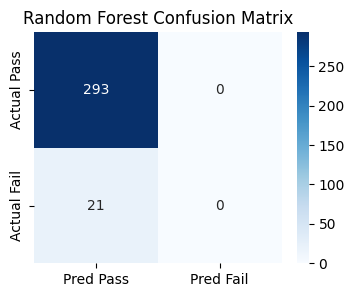

5-Fold CV Defect Recall Scores: [0. 0. 0. 0. 0.]
Mean Recall: 0.0000 (+/- 0.0000)


In [13]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# 1. Confusion Matrix for Random Forest
rf_model = models["Random Forest"]
y_pred_rf = rf_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Pass', 'Pred Fail'],
            yticklabels=['Actual Pass', 'Actual Fail'])
plt.title("Random Forest Confusion Matrix")
plt.show()

# 2. 5-Fold Stratified Cross-Validation (Evaluating Recall on Defect Detection)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_model, X_train_scaled, y_train, cv=cv, scoring='recall')

print(f"5-Fold CV Defect Recall Scores: {np.round(cv_scores, 4)}")
print(f"Mean Recall: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

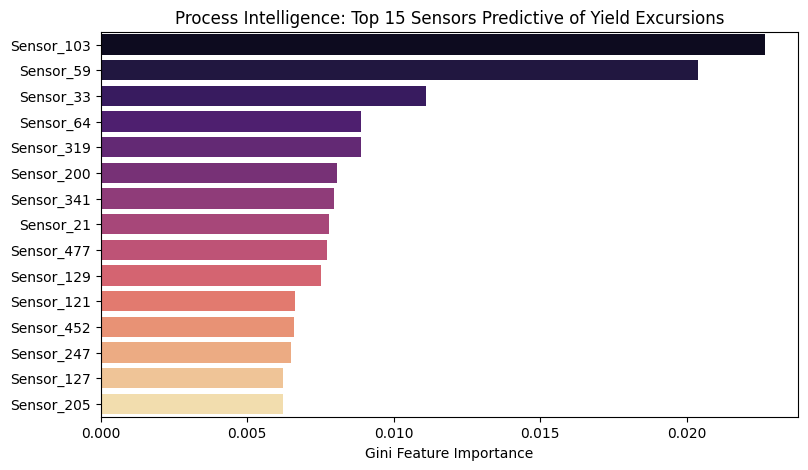

=== IN-LINE DECISION SUPPORT PROTOTYPE ===
Sample Tested          : Instance #0
Actual Verification    : PASS
Model Recommendation   : PASS
Calculated Defect Risk : 7.00%
Top Associated Factor  : Sensor_103


In [14]:
# 1. Extract Top 15 Informative Sensors
importances = rf_model.feature_importances_
sorted_idx = np.argsort(importances)[::-1][:15]

plt.figure(figsize=(9, 5))
sns.barplot(
    x=importances[sorted_idx],
    y=[feature_names[i] for i in sorted_idx],
    palette='magma'
)
plt.title("Process Intelligence: Top 15 Sensors Predictive of Yield Excursions")
plt.xlabel("Gini Feature Importance")
plt.show()

# 2. Single-Run Decision Support Prototype Demo
test_idx = 0
sample_vector = X_test_scaled[test_idx].reshape(1, -1)
true_status = "FAIL" if y_test.iloc[test_idx] == 1 else "PASS"

pred_code = rf_model.predict(sample_vector)[0]
pred_status = "FAIL" if pred_code == 1 else "PASS"
fail_prob = rf_model.predict_proba(sample_vector)[0][1]

print("=== IN-LINE DECISION SUPPORT PROTOTYPE ===")
print(f"Sample Tested          : Instance #{test_idx}")
print(f"Actual Verification    : {true_status}")
print(f"Model Recommendation   : {pred_status}")
print(f"Calculated Defect Risk : {fail_prob * 100:.2f}%")
print("Top Associated Factor  :", feature_names[sorted_idx[0]])